# 16a — Chapter 2 Exercise: ESG Scoring

This notebook works through two fully solved exercises revisiting
Chapter 2's ESG-scoring toolkit: the distribution of a weighted average
of uniform sub-scores, and portfolio-level ESG-score aggregation,
power-law-tilted weighting schemes, and ESG-transition/turnover
matrices.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gamma as gamma_dist, multivariate_normal

color_blue   = "#1f77b4"
color_red    = "#d62728"
color_green  = "#2ca02c"
color_violet = "#ff33ff"
color_black  = "#000000"

plt.rcParams["figure.dpi"] = 100
rng = np.random.default_rng(123)

## Helper functions

`cdf_score1`/`pdf_score1`: CDF/PDF of `S = ω·X1 + (1-ω)·X2` for
`X1,X2 ~ U[0,1]` independent -- a piecewise triangular/trapezoidal
distribution on `[0,1]`. `pdf_score2`: PDF of the average of 3 i.i.d.
`U[0,1]` variables (an Irwin-Hall-type distribution). `gamma_cdf`: a thin
wrapper around the Gamma CDF taking a *rate* parameter `beta`
(`scale=1/beta`). `compute_m_plus`: smallest portfolio size `m` for which
`P(1-ε ≤ S ≤ 1+ε) ≥ p` under a `Gamma(2m,2m)`-distributed
diversification-ratio proxy `S` (mean 1, variance `1/(2m)`).


In [2]:
def cdf_score1(s, omega):
    '''CDF of S = omega*X1 + (1-omega)*X2, X1,X2 ~ iid U[0,1].'''
    s = np.atleast_1d(np.asarray(s, dtype=float))
    assert 0 < omega < 1
    low = min(omega, 1 - omega)
    high = max(omega, 1 - omega)
    val = np.zeros_like(s)
    for k, sk in enumerate(s):
        if sk < 0:
            val[k] = 0.0
        elif sk <= low:
            val[k] = sk**2 / (2 * omega * (1 - omega))
        elif omega <= 0.5 and sk <= (1 - omega):
            val[k] = (2 * sk - omega) / (2 * (1 - omega))
        elif omega >= 0.5 and sk <= omega:
            val[k] = (2 * sk - (1 - omega)) / (2 * omega)
        elif sk <= high:
            val[k] = (2 * sk - omega) / (2 * (1 - omega))
        elif sk <= 1:
            val[k] = 1 - (1 - sk)**2 / (2 * omega * (1 - omega))
        else:
            val[k] = 1.0
    return val


def pdf_score1(s, omega):
    '''PDF of S = omega*X1 + (1-omega)*X2, X1,X2 ~ iid U[0,1].'''
    s = np.atleast_1d(np.asarray(s, dtype=float))
    assert 0 < omega < 1
    val = np.zeros_like(s)
    for k, sk in enumerate(s):
        if sk < 0 or sk > 1:
            val[k] = 0.0
        elif sk <= min(omega, 1 - omega):
            val[k] = sk / (omega * (1 - omega))
        elif omega <= 0.5 and sk <= (1 - omega):
            val[k] = 1 / (1 - omega)
        elif omega >= 0.5 and sk <= omega:
            val[k] = 1 / omega
        elif sk <= max(omega, 1 - omega):
            val[k] = 1 / (1 - omega)
        else:
            val[k] = (1 - sk) / (omega * (1 - omega))
    return val


def pdf_score2(s):
    '''PDF of the sample mean of 3 iid U[0,1] variables.'''
    s = np.asarray(s, dtype=float)
    val = np.zeros_like(s)
    idx1 = (s >= 0) & (s <= 1 / 3)
    val[idx1] = 27 * s[idx1]**2 / 2
    idx2 = (s > 1 / 3) & (s <= 2 / 3)
    val[idx2] = (27 * s[idx2]**2 - 9 * (3 * s[idx2] - 1)**2) / 2
    idx3 = (s > 2 / 3) & (s <= 1)
    val[idx3] = 3 * (3 - 3 * s[idx3])**2 / 2
    return val


def gamma_cdf(x, alpha, beta):
    '''Gamma CDF parameterized by shape a=alpha and rate b=beta (scale=1/beta).'''
    return gamma_dist.cdf(x, a=alpha, scale=1.0 / beta)


def compute_m_plus(m, p, epsilon):
    alpha = 2 * m
    beta = 2 * m
    pr = gamma_cdf(1 + epsilon, alpha, beta) - gamma_cdf(1 - epsilon, alpha, beta)
    cnd = pr >= p
    return np.nan if not cnd.any() else m[cnd].min()

## Question 1.a — feasible-weight-combination diagrams

For 4 `(ω,s)` combinations, the diagram shows the unit square (the
`(X1,X2)` support), the iso-score line `ω·x1+(1-ω)·x2=s` (dashed blue),
its restriction to the unit square (solid red, via `missex`-style
masking of the out-of-square segment), and the two boundary points where
the iso-score line crosses the square's edges (markers) -- the same
"corner-case" geometry that produces `cdf_score1`'s 5 piecewise branches.


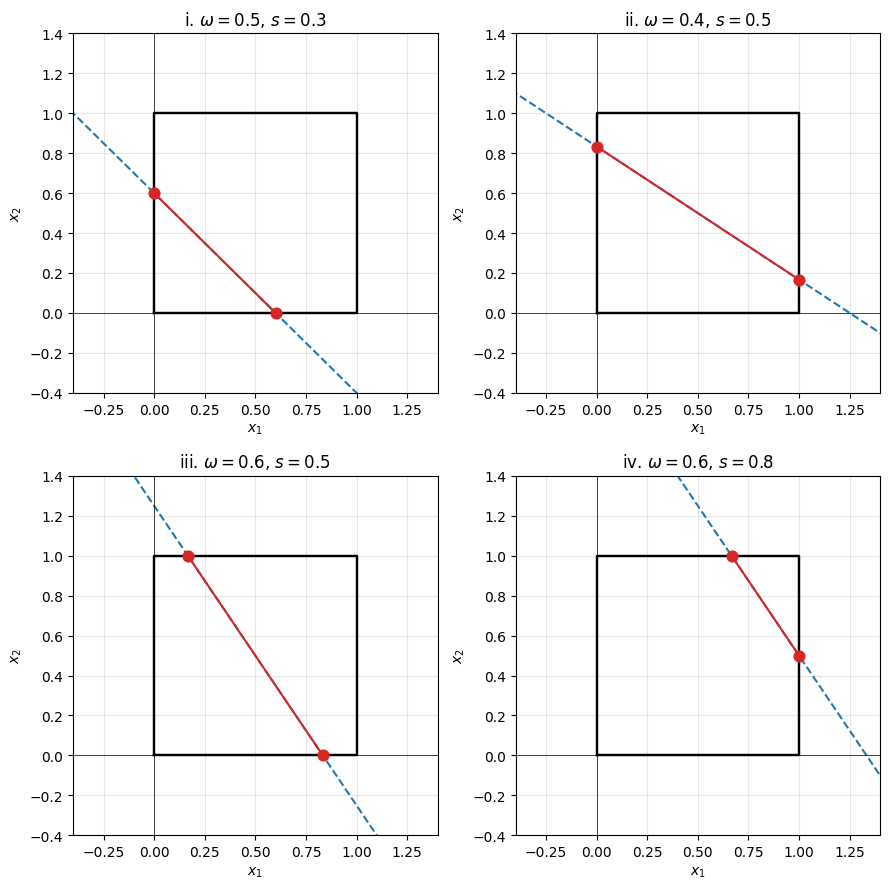

In [3]:
def missex(x, cnd):
    y = np.array(x, dtype=float, copy=True)
    y[cnd] = np.nan
    return y


def iso_score_corners(omega, s):
    '''The two points where the line omega*x1+(1-omega)*x2=s crosses the
    unit square's boundary (one of 4 branches, depending on where s falls
    relative to omega and 1-omega).'''
    if 0 <= s <= min(omega, 1 - omega):
        p1 = (0, s / (1 - omega))
        p2 = (s / omega, 0)
    elif omega <= 0.5 and omega <= s <= 1 - omega:
        p1 = (0, s / (1 - omega))
        p2 = (1, (s - omega) / (1 - omega))
    elif omega > 0.5 and 1 - omega <= s <= omega:
        p1 = (s / omega, 0)
        p2 = ((s - (1 - omega)) / omega, 1)
    elif max(omega, 1 - omega) <= s <= 1:
        p1 = ((s - (1 - omega)) / omega, 1)
        p2 = (1, (s - omega) / (1 - omega))
    else:
        raise ValueError(f"s={s} out of [0,1] for omega={omega}")
    return p1, p2


fig, axes = plt.subplots(2, 2, figsize=(9, 9))
scenarios = [(0.5, 0.3, "i."), (0.4, 0.5, "ii."), (0.6, 0.5, "iii."), (0.6, 0.8, "iv.")]
for ax, (omega, s, tag) in zip(axes.flat, scenarios):
    ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], "-", color=color_black, linewidth=1.75)
    x1 = np.arange(-2, 2 + 1e-9, 0.005)
    x2 = (s - omega * x1) / (1 - omega)
    cnd = (x1 < 0) | (x1 > 1) | (x2 < 0) | (x2 > 1)
    ax.plot(x1, x2, "--", color=color_blue, linewidth=1.5)
    ax.plot(missex(x1, cnd), missex(x2, cnd), "-", color=color_red, linewidth=1.5)
    p1, p2 = iso_score_corners(omega, s)
    ax.scatter([p1[0], p2[0]], [p1[1], p2[1]], s=60, color=color_red, zorder=5)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_title(f"{tag} $\\omega={omega}$, $s={s}$")
    ax.set_xlim(-0.4, 1.4); ax.set_ylim(-0.4, 1.4)
    ax.axhline(0, color="black", linewidth=0.5); ax.axvline(0, color="black", linewidth=0.5)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Questions 1.b/1.c — CDF and PDF of the weighted score

`ω` and `1-ω` give the same distribution by symmetry, so only
`ω=0.1,0.3,0.5` are plotted, with legend labels `"ω=0.1 or 0.9"` etc. to
note the symmetry explicitly.


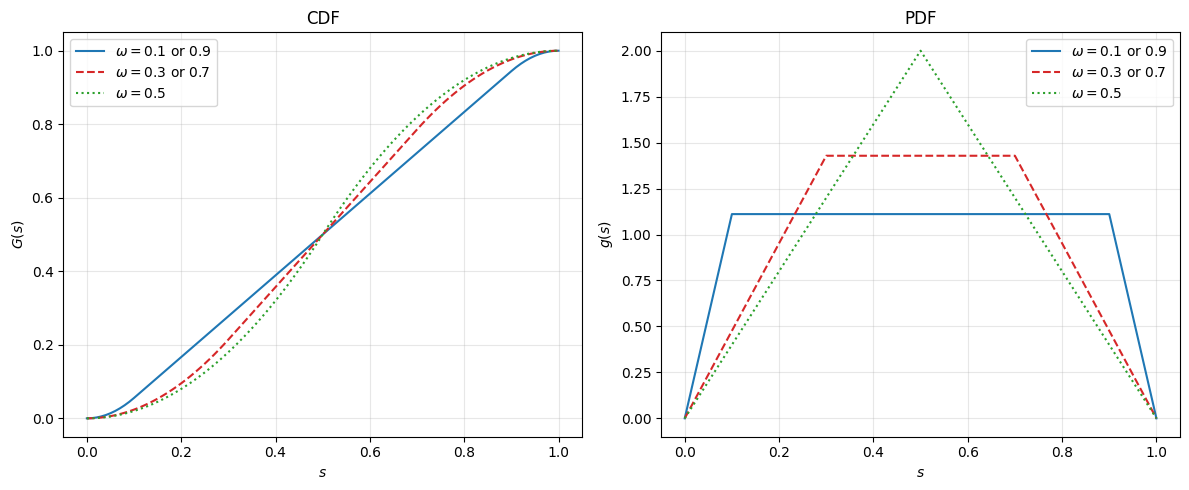

In [4]:
s_grid = np.arange(0, 1 + 1e-9, 0.01)
omegas = [0.1, 0.3, 0.5]
labels = ["$\\omega=0.1$ or $0.9$", "$\\omega=0.3$ or $0.7$", "$\\omega=0.5$"]
styles = ["-", "--", ":"]
colors = [color_blue, color_red, color_green]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for om, lbl, ls, c in zip(omegas, labels, styles, colors):
    axes[0].plot(s_grid, cdf_score1(s_grid, om), ls, color=c, linewidth=1.5, label=lbl)
    axes[1].plot(s_grid, pdf_score1(s_grid, om), ls, color=c, linewidth=1.5, label=lbl)
axes[0].set_xlabel("$s$"); axes[0].set_ylabel("$G(s)$"); axes[0].legend(); axes[0].set_title("CDF")
axes[1].set_xlabel("$s$"); axes[1].set_ylabel("$g(s)$"); axes[1].legend(); axes[1].set_title("PDF")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Question 2.e — PDF of the 3-factor average score

`Score = (X1+X2+X3)/3`, `X_j ~ iid U[0,1]` -- the classic Irwin-Hall-type
triangular-ish density, symmetric around `s=0.5`.


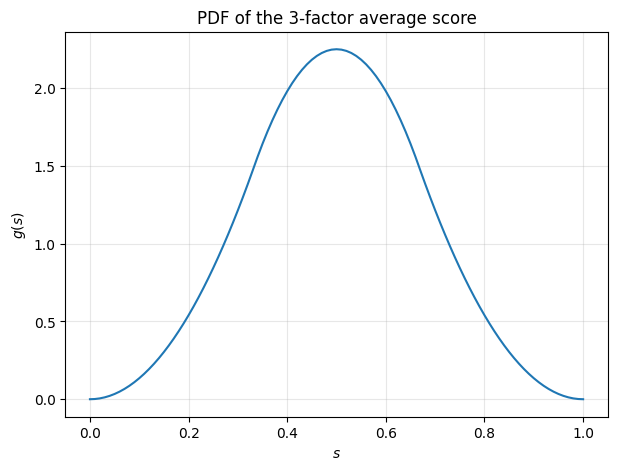

In [5]:
g = pdf_score2(s_grid)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(s_grid, g, "-", color=color_blue, linewidth=1.5)
ax.set_xlabel("$s$"); ax.set_ylabel("$g(s)$"); ax.grid(True, alpha=0.3)
ax.set_title("PDF of the 3-factor average score")
plt.show()

## Question 4.(d) — portfolio-size diversification thresholds

A diversification-ratio proxy `S ~ Gamma(2m,2m)` has `E[S]=1`,
`var(S)=1/(2m)` for a portfolio of `m` holdings (panel i). `m_plus(p,ε)`
(panels ii-iv) is the smallest `m` such that `P(1-ε≤S≤1+ε)≥p` -- how many
holdings are needed before diversification concentrates within `±ε` of 1
with confidence `p`.


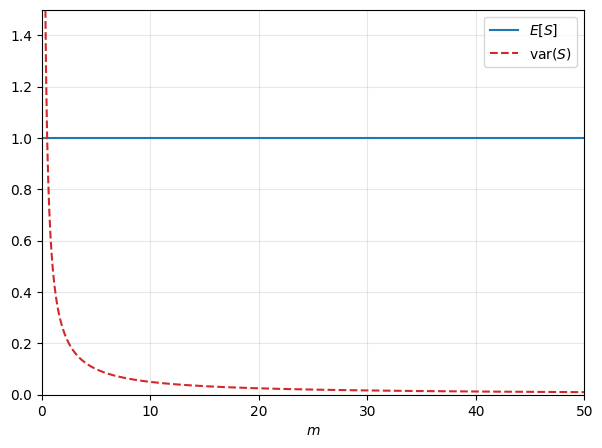

Q4(d)(ii): smallest m with P(0.95<=S<=1.05)>=99% is m_plus = 1327.49


In [6]:
m = np.arange(0, 50 + 1e-9, 0.1)
mu_m = np.ones_like(m)
var_m = 1 / (2 * m[1:])  # m=0 undefined (division by zero), so the variance curve starts at m[1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(m, mu_m, "-", color=color_blue, linewidth=1.5, label="$E[S]$")
ax.plot(m[1:], var_m, "--", color=color_red, linewidth=1.5, label="$\\mathrm{var}(S)$")
ax.set_xlabel("$m$"); ax.set_xlim(0, 50); ax.set_ylim(0, 1.5); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

# Question 4.(d).ii -- single point lookup
m_fine = np.arange(1300, 1400 + 1e-9, 0.01)
pr = gamma_cdf(1.05, 2 * m_fine, 2 * m_fine) - gamma_cdf(0.95, 2 * m_fine, 2 * m_fine)
m_plus_single = m_fine[pr >= 0.99].min()
print(f"Q4(d)(ii): smallest m with P(0.95<=S<=1.05)>=99% is m_plus = {m_plus_single:.2f}")

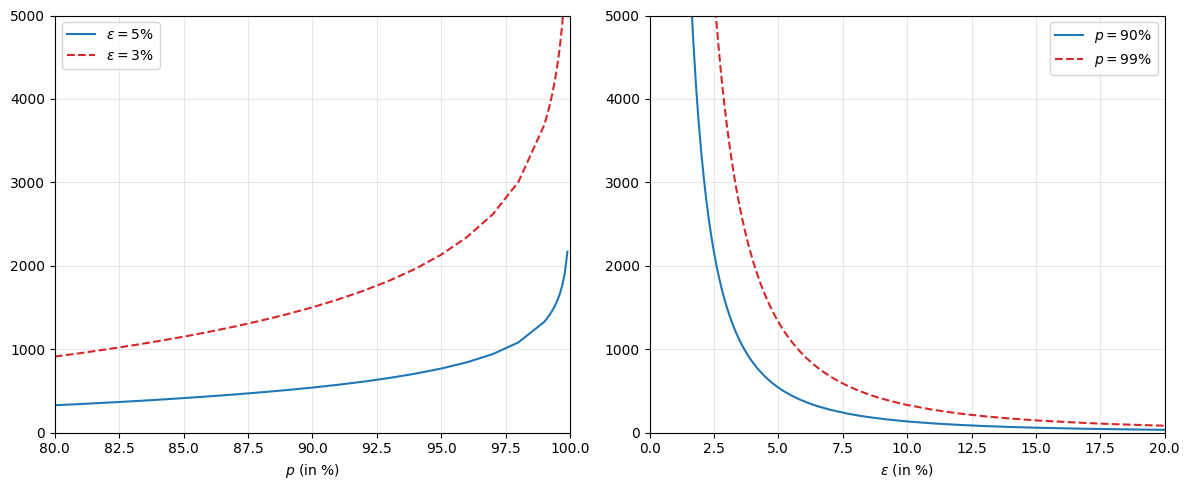

In [7]:
# Questions 4.(d).iii & 4.(d).iv -- m_plus(p,epsilon) sweeps
m_grid = np.arange(1, 6000 + 1, 1.0)

p1_grid = np.concatenate([np.arange(0.80, 0.99 + 1e-9, 0.01), np.arange(0.991, 0.999 + 1e-9, 0.001)])
m1_plus = np.array([compute_m_plus(m_grid, p, 0.05) for p in p1_grid])
m2_plus = np.array([compute_m_plus(m_grid, p, 0.03) for p in p1_grid])

eps3_grid = np.concatenate([np.arange(0.0, 0.10 + 1e-9, 0.001), np.arange(0.11, 0.99 + 1e-9, 0.01)])
m3_plus = np.array([compute_m_plus(m_grid, 0.90, e) for e in eps3_grid])
eps4_grid = np.concatenate([np.arange(0.0, 0.10 + 1e-9, 0.001), np.arange(0.11, 0.20 + 1e-9, 0.01)])
m4_plus = np.array([compute_m_plus(m_grid, 0.99, e) for e in eps4_grid])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(100 * p1_grid, m1_plus, "-", color=color_blue, linewidth=1.5, label="$\\varepsilon=5\\%$")
axes[0].plot(100 * p1_grid, m2_plus, "--", color=color_red, linewidth=1.5, label="$\\varepsilon=3\\%$")
axes[0].set_xlabel("$p$ (in %)"); axes[0].set_xlim(80, 100); axes[0].set_ylim(0, 5000); axes[0].legend()
axes[1].plot(100 * eps3_grid, m3_plus, "-", color=color_blue, linewidth=1.5, label="$p=90\\%$")
axes[1].plot(100 * eps4_grid, m4_plus, "--", color=color_red, linewidth=1.5, label="$p=99\\%$")
axes[1].set_xlabel("$\\varepsilon$ (in %)"); axes[1].set_xlim(0, 20); axes[1].set_ylim(0, 5000); axes[1].legend()
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## ESG aggregation, power-law tilts, transition matrices

8 fictitious names' E/S/G sub-scores (inline data).


In [8]:
e_score = np.array([-2.80, -1.80, -1.75, 0.60, 0.75, 1.30, 1.90, 2.70])
s_score = np.array([-1.70, -1.90, 0.75, -1.60, 1.85, 1.05, 0.90, 0.70])
g_score = np.array([0.30, -0.70, -2.75, 2.60, 0.45, 2.35, 2.20, 1.70])
n = len(e_score)

# Q1.a -- 40/40/20 ESG aggregation
esg_score = 0.40 * e_score + 0.40 * s_score + 0.20 * g_score
print("Q1.a  ESG(i) per name:", np.round(esg_score, 4))

# Q1.b -- equal-weighted portfolio ESG score
x_eq = np.ones(n) / n
s1_portfolio = np.sum(x_eq * esg_score)
print(f"Q1.b  ESG(x) = {s1_portfolio:.4f}")

Q1.a  ESG(i) per name: [-1.74 -1.62 -0.95  0.12  1.13  1.41  1.56  1.7 ]
Q1.b  ESG(x) = 0.2013


## Question 2.c — power-law weight-tilt density

`f(t) = α·t^(α-1)` on `[0,1]` for several `α` -- the density implied by
`v = U^(1/α)` for `U~U[0,1]` (the transform used below to build
power-law-tilted portfolio weights).


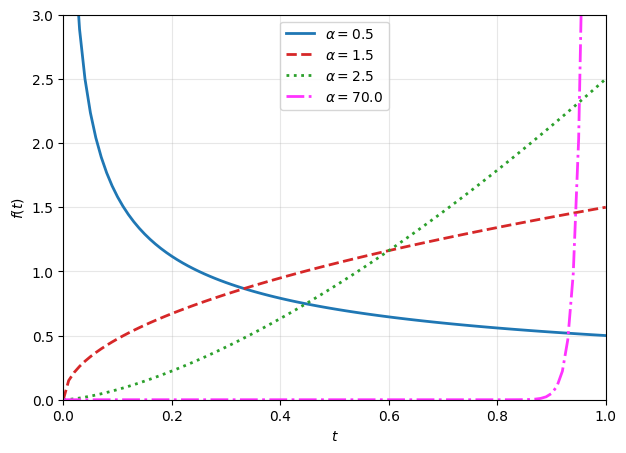

In [9]:
alpha_vec = np.array([0.5, 1.5, 2.5, 70.0])
t = np.arange(0, 1 + 1e-9, 1 / 100)
with np.errstate(divide="ignore"):  # t=0 with alpha<1: t^(alpha-1) -> inf, a genuine density
    pdf_t = alpha_vec * t[:, None] ** (alpha_vec - 1)  # this is the true (integrable) power-law density's shape

alpha_labels = ["$\\alpha=0.5$", "$\\alpha=1.5$", "$\\alpha=2.5$", "$\\alpha=70.0$"]
alpha_styles = ["-", "--", ":", "-."]
alpha_colors = [color_blue, color_red, color_green, color_violet]

fig, ax = plt.subplots(figsize=(7, 5))
for j in range(4):
    ax.plot(t, pdf_t[:, j], alpha_styles[j], color=alpha_colors[j], linewidth=2.0, label=alpha_labels[j])
ax.set_xlabel("$t$"); ax.set_ylabel("$f(t)$"); ax.set_xlim(0, 1); ax.set_ylim(0, 3); ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Question 2.d — a single draw of power-law-tilted weights

`n=50` holdings, one shared uniform draw `u`, weights `v=u^(1/α)`
normalized to sum to 1 and sorted in descending order, for each `α`. The
**same** `u` is reused across all 4 `α` panels (only the weighting
exponent changes), not 4 independent draws, to isolate the effect of `α`
on the resulting weight concentration.


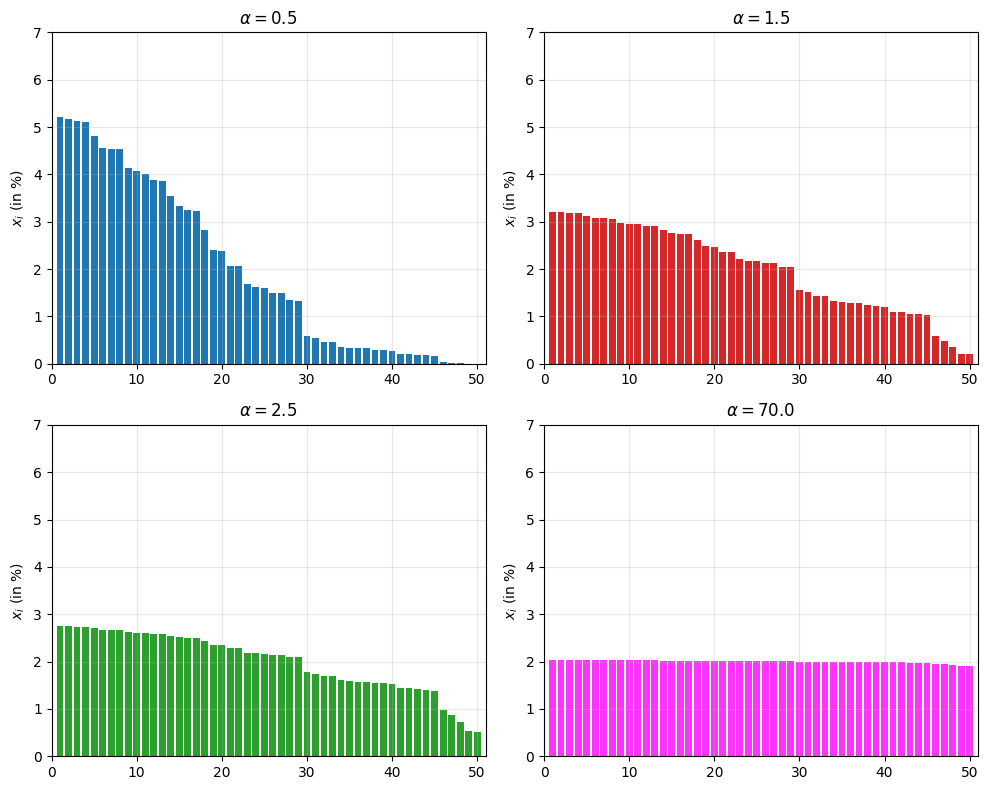

Sanity check: each column of v_single sums to 100% -> [100. 100. 100. 100.]


In [10]:
n_holdings = 50
u_single = rng.random(n_holdings)
v_single = u_single[:, None] ** (1.0 / alpha_vec)          # (n,4), same u for every alpha
v_single = v_single / v_single.sum(axis=0, keepdims=True)   # normalize each column to sum to 1
v_single = -np.sort(-v_single, axis=0)                       # descending sort, per column

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, j in zip(axes.flat, range(4)):
    ax.bar(np.arange(1, n_holdings + 1), 100 * v_single[:, j], color=alpha_colors[j], edgecolor="none")
    ax.set_xlim(0, n_holdings + 1); ax.set_ylim(0, 7); ax.set_xticks(range(0, 51, 10))
    ax.set_title(alpha_labels[j]); ax.set_ylabel("$x_i$ (in %)")
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
print(f"Sanity check: each column of v_single sums to 100% -> {np.round(100*v_single.sum(axis=0), 6)}")

## Question 2.e — Monte Carlo distribution of the weighted average score

`S(x) = Σ x_i·s_i` for `s_i ~ iid N(0,1)` (uncorrelated with the
weight-generating draw), `x` power-law-tilted as above. `nS=50,000`
Monte Carlo draws per `α`, vectorized over the draw axis: each draw
independently redraws `u∈R^n` and `s∈R^n`, so all `nS` draws are computed
as array operations at once rather than one at a time.


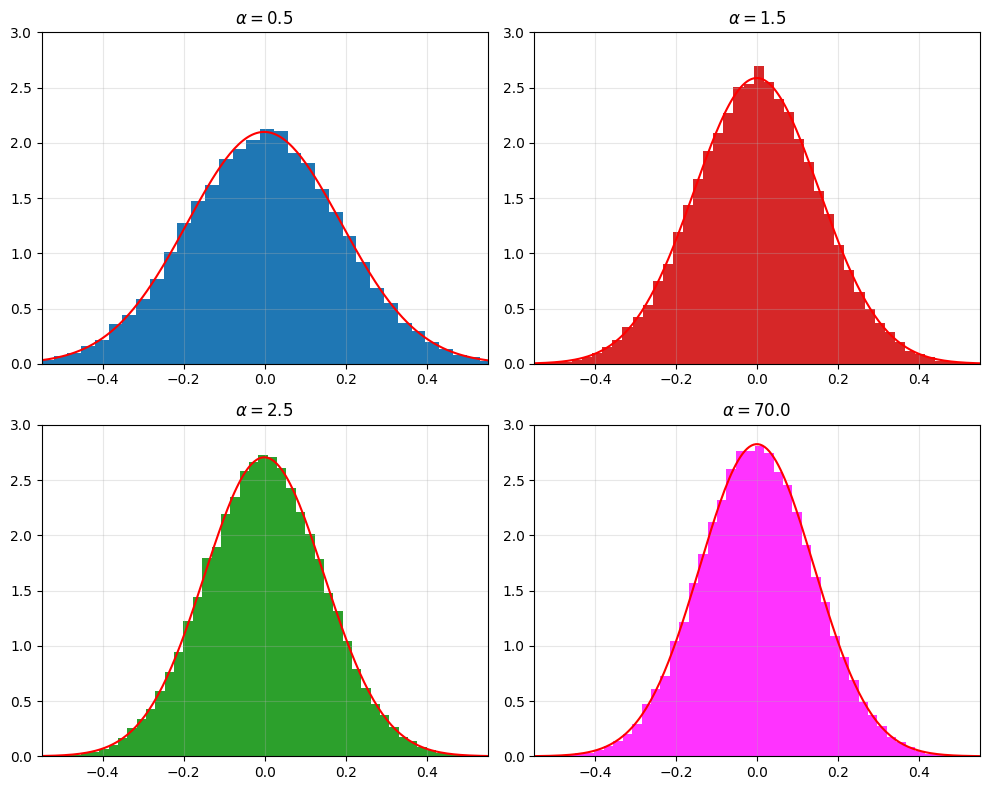

Q2.e mean(s_x) per alpha (should be ~0, s uncorrelated with weights): [-0.001  -0.0008 -0.0007 -0.0005]


In [11]:
nS = 50_000


def mc_weighted_score(alpha_vec, nS, n, rng, g1=None, g2=None):
    '''Compute S(x) = sum(x*s) for nS Monte Carlo draws at once, vectorized
    over the draw axis. If g1/g2 are given (Q2.g/Q2.h), weights are tilted
    from u1=Phi(g1) and returns are s=g2 (correlated case); otherwise draws
    fresh independent u (weights) and s (returns) per column (Q2.e).'''
    if g1 is None:
        u1 = rng.random((n, nS))
        s = rng.standard_normal((n, nS))
    else:
        u1 = norm.cdf(g1)
        s = g2
    s_x = np.empty((nS, len(alpha_vec)))
    for j, a in enumerate(alpha_vec):
        v = u1 ** (1.0 / a)
        x = v / v.sum(axis=0, keepdims=True)
        s_x[:, j] = (x * s).sum(axis=0)
    return s_x


s_x_2e = mc_weighted_score(alpha_vec, nS, n_holdings, rng)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, j in zip(axes.flat, range(4)):
    ax.hist(s_x_2e[:, j], bins=50, density=True, color=alpha_colors[j])
    xg = np.linspace(-0.55, 0.55, 200)
    mu_fit, sigma_fit = s_x_2e[:, j].mean(), s_x_2e[:, j].std(ddof=1)
    ax.plot(xg, norm.pdf(xg, mu_fit, sigma_fit), "r-")
    ax.set_xlim(-0.55, 0.55); ax.set_ylim(0, 3); ax.set_title(alpha_labels[j])
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
print("Q2.e mean(s_x) per alpha (should be ~0, s uncorrelated with weights):",
      np.round(s_x_2e.mean(axis=0), 4))

## Question 2.g — correlated weights and returns (`ρ=0.5`)

Now the "true" ESG factor `g1` (driving weight tilts via `u1=Φ(g1)`) and
the realized return/score `g2 = ρ·g1 + √(1-ρ²)·ε` are correlated at
`ρ=0.5` -- names with a higher "true" ESG factor tend to get tilted
*and* to realize a higher score, so `S(x)` should now be biased away from
0.


Q2.g mean(s_x) per alpha (rho=0.5, should now be > 0): [0.418  0.2106 0.1422 0.0062]


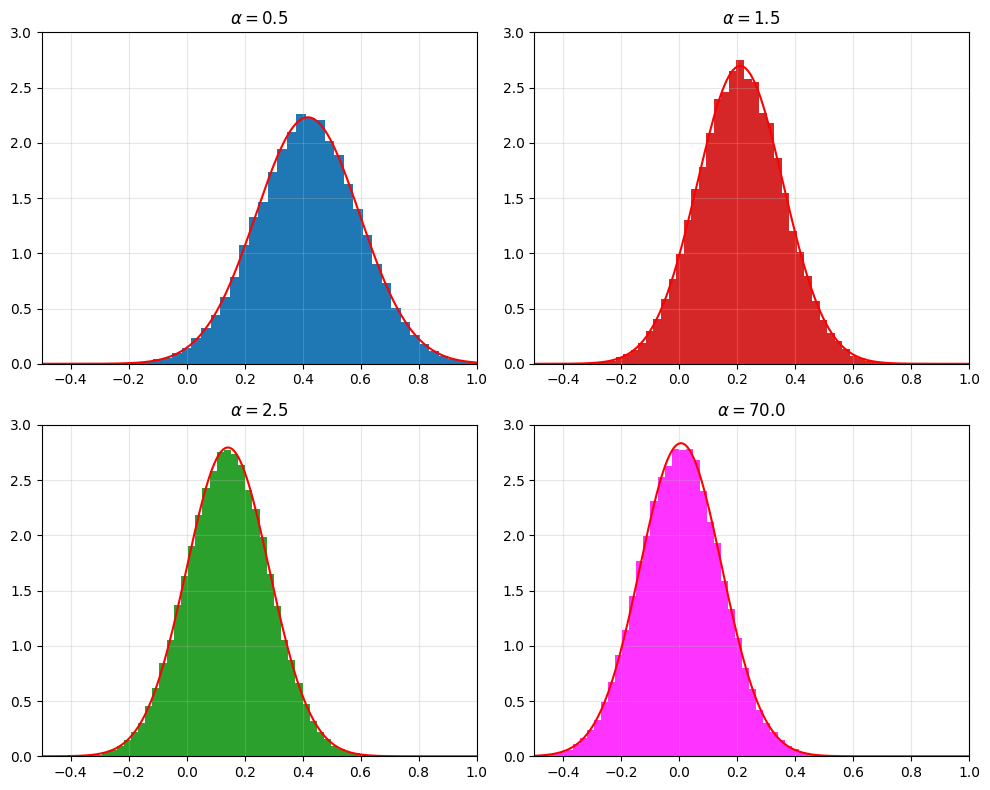

In [12]:
rho = 0.5
g1 = rng.standard_normal((n_holdings, nS))
g2 = rho * g1 + np.sqrt(1 - rho**2) * rng.standard_normal((n_holdings, nS))
s_x_2g = mc_weighted_score(alpha_vec, nS, n_holdings, rng, g1=g1, g2=g2)
print("Q2.g mean(s_x) per alpha (rho=0.5, should now be > 0):", np.round(s_x_2g.mean(axis=0), 4))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, j in zip(axes.flat, range(4)):
    ax.hist(s_x_2g[:, j], bins=50, density=True, color=alpha_colors[j])
    xg = np.linspace(-0.5, 1.0, 200)
    mu_fit, sigma_fit = s_x_2g[:, j].mean(), s_x_2g[:, j].std(ddof=1)
    ax.plot(xg, norm.pdf(xg, mu_fit, sigma_fit), "r-")
    ax.set_xlim(-0.5, 1.0); ax.set_ylim(0, 3); ax.set_title(alpha_labels[j])
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Question 2.h — `E[S(x)]` as a function of `ρ`

Sweeping `ρ` from 0 to 0.999 (`nS=10,000` per point -- fewer draws than
Q2.g since this repeats the whole simulation 12 times). The `α=70` panel
(near-equal weighting) should stay essentially flat at 0 regardless of
`ρ`, since equal weights place no systematic bet on the ESG factor;
`α=0.5` (most concentrated tilt) should show the strongest `ρ`-sensitivity.


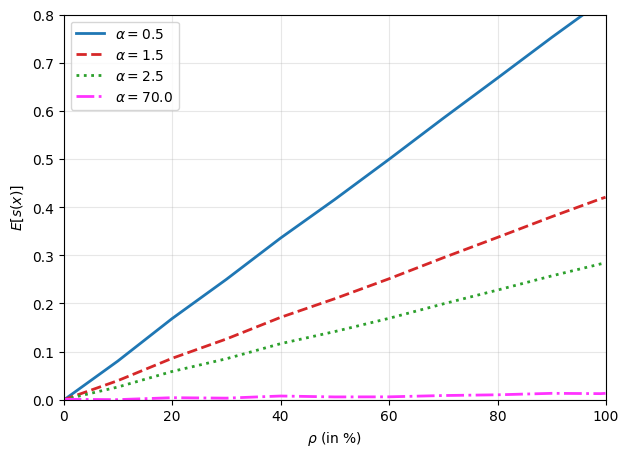

In [13]:
rho_vec = np.concatenate([np.arange(0, 0.9 + 1e-9, 0.1), [0.99, 0.999]])
nS_h = 10_000
mean_s_x_h = np.empty((len(rho_vec), 4))
for i, rho_i in enumerate(rho_vec):
    g1h = rng.standard_normal((n_holdings, nS_h))
    g2h = rho_i * g1h + np.sqrt(1 - rho_i**2) * rng.standard_normal((n_holdings, nS_h))
    mean_s_x_h[i] = mc_weighted_score(alpha_vec, nS_h, n_holdings, rng, g1=g1h, g2=g2h).mean(axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(100 * rho_vec, mean_s_x_h[:, 0], "-", color=color_blue, linewidth=2.0, label=alpha_labels[0])
ax.plot(100 * rho_vec, mean_s_x_h[:, 1], "--", color=color_red, linewidth=2.0, label=alpha_labels[1])
ax.plot(100 * rho_vec, mean_s_x_h[:, 2], ":", color=color_green, linewidth=2.0, label=alpha_labels[2])
ax.plot(100 * rho_vec, mean_s_x_h[:, 3], "-.", color=color_violet, linewidth=2.0, label=alpha_labels[3])
ax.set_xlabel("$\\rho$ (in %)"); ax.set_ylabel("$E[s(x)]$"); ax.set_xlim(0, 100); ax.set_ylim(0, 0.8)
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## Questions 3.a-d — threshold/quantile examples

Four small threshold vectors used later (Question 4) to build ESG-bucket
transition matrices: `s1` = fixed cut points `{-1.5,0,1.5}`; `s2`,`s3` =
quantiles of `N(0,1)` at `{25,50,75}%` and `{10,50,90}%`; `s4` = quantiles
at `{20,40,60,80}%` (computed for completeness but not used again in
Question 4).


In [14]:
s1 = np.array([-1.50, 0.0, 1.50])
cdf_s1 = np.concatenate([[0.0], norm.cdf(s1), [1.0]])
pdf_s1 = np.concatenate([[np.nan], np.diff(cdf_s1)])
print("Q3.a  bucket probabilities (%) for s1:", np.round(100 * pdf_s1, 2))

s2 = norm.ppf([0.25, 0.50, 0.75])
print("Q3.b  s2 (quantiles at 25/50/75%):", np.round(s2, 4))

s3 = norm.ppf([0.10, 0.50, 0.90])
print("Q3.c  s3 (quantiles at 10/50/90%):", np.round(s3, 4))

s4 = norm.ppf([0.20, 0.40, 0.60, 0.80])
print("Q3.d  s4 (quantiles at 20/40/60/80%, not reused below):", np.round(s4, 4))

Q3.a  bucket probabilities (%) for s1: [  nan  6.68 43.32 43.32  6.68]
Q3.b  s2 (quantiles at 25/50/75%): [-0.6745  0.      0.6745]
Q3.c  s3 (quantiles at 10/50/90%): [-1.2816  0.      1.2816]
Q3.d  s4 (quantiles at 20/40/60/80%, not reused below): [-0.8416 -0.2533  0.2533  0.8416]


## Questions 4.h-j — ESG-bucket transition and turnover matrices

`esg_transition_matrix(s, σ)`: given `K-1` threshold points `s` (defining
`K` ESG buckets via `-∞=s_0<s_1<...<s_{K-1}<s_K=+∞`), models the "true"
ESG factor `g1~N(0,1)` and a noisy re-measurement `g2=g1+σ·ε`
(`ε~N(0,1)` independent), so `(g1,g2)` is bivariate normal with
`Cov(g1,g2)=1`, `var(g2)=1+σ²` -- and computes the `K×K` matrix of
conditional bucket-transition probabilities `P(g2∈bucket k | g1∈bucket j)`
via the two-sided bivariate-normal rectangle probability, computed here
by inclusion-exclusion on the joint CDF:
`P(a<X<b,c<Y<d)=F(b,d)-F(a,d)-F(b,c)+F(a,c)`. `to = 1-diag(p)` is the
per-bucket turnover (probability of *not* staying in the same bucket);
`to_system = Σ cdf·to` is the overall (probability-weighted) turnover.


In [15]:
def rectangle_prob(mvn, xl, xu):
    return (mvn.cdf([xu[0], xu[1]]) - mvn.cdf([xl[0], xu[1]])
            - mvn.cdf([xu[0], xl[1]]) + mvn.cdf([xl[0], xl[1]]))


def esg_transition_matrix(s, sigma):
    K = 1 + len(s)
    s_ext = np.sort(np.concatenate([[-np.inf], s, [np.inf]]))
    p = np.zeros((K, K))
    cdf = np.zeros(K)
    mvn = multivariate_normal(mean=[0.0, 0.0], cov=[[1.0, 1.0], [1.0, 1.0 + sigma**2]], allow_singular=True)
    for j in range(K):
        cdf1 = norm.cdf(s_ext[j + 1]) - norm.cdf(s_ext[j])
        cdf[j] = cdf1
        for k in range(K):
            cdf2 = rectangle_prob(mvn, [s_ext[j], s_ext[k]], [s_ext[j + 1], s_ext[k + 1]])
            p[j, k] = cdf2 / cdf1
    to = 1 - np.diag(p)
    to_system = np.sum(cdf * to)
    return p, cdf, to, to_system


sigma_h = 0.10
for label, s_vec in [("s1", s1), ("s2", s2), ("s3", s3)]:
    p, cdf, to, to_system = esg_transition_matrix(s_vec, sigma_h)
    print(f"--- Q4.h {label} (sigma={sigma_h}) ---")
    print("  row sums of p (should each be 100%):", np.round(100 * p.sum(axis=1), 4))
    print("  cdf (bucket probabilities, %):", np.round(100 * cdf, 2))
    print("  to (per-bucket turnover, %):  ", np.round(100 * to, 2))
    print(f"  to_system (overall turnover, %): {100*to_system:.2f}")

--- Q4.h s1 (sigma=0.1) ---
  row sums of p (should each be 100%): [100. 100. 100. 100.]
  cdf (bucket probabilities, %): [ 6.68 43.32 43.32  6.68]
  to (per-bucket turnover, %):   [7.04 4.97 4.97 7.04]
  to_system (overall turnover, %): 5.25
--- Q4.h s2 (sigma=0.1) ---
  row sums of p (should each be 100%): [100. 100. 100. 100.]
  cdf (bucket probabilities, %): [25. 25. 25. 25.]
  to (per-bucket turnover, %):   [ 4.85 11.62 11.62  4.85]
  to_system (overall turnover, %): 8.23
--- Q4.h s3 (sigma=0.1) ---
  row sums of p (should each be 100%): [100. 100. 100. 100.]
  cdf (bucket probabilities, %): [10. 40. 40. 10.]
  to (per-bucket turnover, %):   [6.46 5.86 5.86 6.46]
  to_system (overall turnover, %): 5.98


Turnover vs. `σ` (Question 4.i) for the three threshold sets, and
turnover vs. the number of buckets `K` (Question 4.j) for three `σ`
levels. For `K=1` (a single bucket covering everything) turnover is
trivially `0`, which coincides with the mathematically correct answer:
with only one bucket there is nothing to transition out of, so `K=1`'s
turnover is handled directly rather than as a special case.


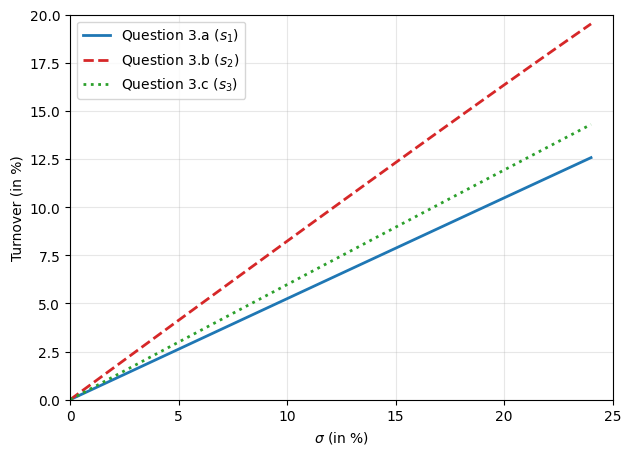

In [16]:
sigma_grid = np.arange(0.0001, 0.25 + 1e-9, 0.01)
to_i = np.empty((len(sigma_grid), 3))
for i, sig in enumerate(sigma_grid):
    for j, s_vec in enumerate([s1, s2, s3]):
        to_i[i, j] = esg_transition_matrix(s_vec, sig)[3]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(100 * sigma_grid, 100 * to_i[:, 0], "-", color=color_blue, linewidth=2.0, label="Question 3.a ($s_1$)")
ax.plot(100 * sigma_grid, 100 * to_i[:, 1], "--", color=color_red, linewidth=2.0, label="Question 3.b ($s_2$)")
ax.plot(100 * sigma_grid, 100 * to_i[:, 2], ":", color=color_green, linewidth=2.0, label="Question 3.c ($s_3$)")
ax.set_xlabel("$\\sigma$ (in %)"); ax.set_ylabel("Turnover (in %)")
ax.set_xlim(0, 25); ax.set_ylim(0, 20); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

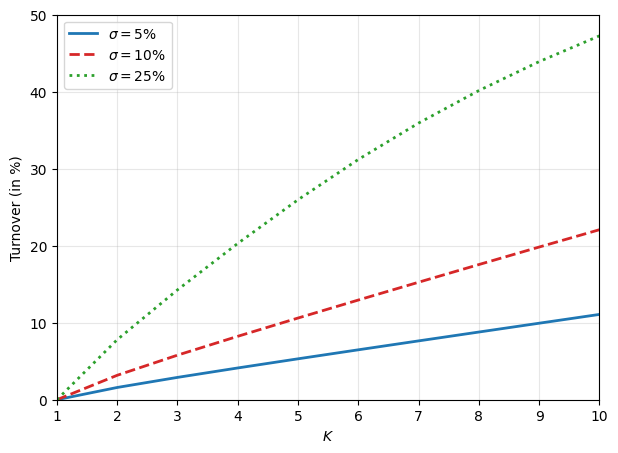

In [17]:
sigma_j = [0.05, 0.10, 0.25]
K_grid = np.arange(1, 11)
to_j = np.zeros((len(K_grid), 3))
for ik, K in enumerate(K_grid):
    if K == 1:
        continue  # trivial 0 turnover: a single bucket has nothing to transition out of
    cdf_pts = np.arange(1, K) / K
    s_k = norm.ppf(cdf_pts)
    for j, sig in enumerate(sigma_j):
        to_j[ik, j] = esg_transition_matrix(s_k, sig)[3]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(K_grid, 100 * to_j[:, 0], "-", color=color_blue, linewidth=2.0, label="$\\sigma=5\\%$")
ax.plot(K_grid, 100 * to_j[:, 1], "--", color=color_red, linewidth=2.0, label="$\\sigma=10\\%$")
ax.plot(K_grid, 100 * to_j[:, 2], ":", color=color_green, linewidth=2.0, label="$\\sigma=25\\%$")
ax.set_xlabel("$K$"); ax.set_ylabel("Turnover (in %)")
ax.set_xlim(1, 10); ax.set_ylim(0, 50); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

## Sanity checks

In [18]:
checks = []

# cdf_score1 differentiates (numerically) to pdf_score1
for om in [0.3, 0.5, 0.7]:
    sg = np.linspace(0.001, 0.999, 2000)
    d = np.gradient(cdf_score1(sg, om), sg)
    err = np.max(np.abs(d - pdf_score1(sg, om))[10:-10])  # skip edges where gradient is less accurate
    checks.append((f"cdf_score1 differentiates to pdf_score1 (omega={om})", err < 5e-3, f"max err={err:.2e}"))

# pdf_score1 integrates to 1
for om in [0.2, 0.5, 0.8]:
    area = np.trapezoid(pdf_score1(s_grid, om), s_grid)
    checks.append((f"pdf_score1 integrates to 1 (omega={om})", abs(area - 1) < 1e-3, f"area={area:.6f}"))

# pdf_score2 integrates to 1 and matches its own CDF differences
area2 = np.trapezoid(pdf_score2(s_grid), s_grid)
checks.append(("pdf_score2 integrates to 1", abs(area2 - 1) < 1e-3, f"area={area2:.6f}"))

# power-law density f(t)=alpha*t^(alpha-1) integrates to 1 for each alpha (even alpha=0.5's integrable singularity at 0)
for a in alpha_vec:
    tg = np.linspace(1e-6, 1, 200_000)
    area_pl = np.trapezoid(a * tg**(a - 1), tg)
    checks.append((f"power-law density integrates to 1 (alpha={a})", abs(area_pl - 1) < 2e-3, f"area={area_pl:.6f}"))

# compute_m_plus consistency: at the returned m_plus, coverage probability should be >= p,
# and just below the returned grid point it should be < p (grid-resolution monotonicity check)
for p_target, eps in [(0.90, 0.05), (0.95, 0.03)]:
    m_star = compute_m_plus(m_grid, p_target, eps)
    pr_at = gamma_cdf(1 + eps, 2 * m_star, 2 * m_star) - gamma_cdf(1 - eps, 2 * m_star, 2 * m_star)
    checks.append((f"compute_m_plus(p={p_target},eps={eps}) coverage >= p", pr_at >= p_target - 1e-9, f"pr={pr_at:.4f}"))

# esg_transition_matrix: every row of p sums to 1, cdf sums to 1, to_system in [0,1]
for s_vec in [s1, s2, s3]:
    p, cdf, to, to_system = esg_transition_matrix(s_vec, 0.10)
    checks.append((f"esg_transition_matrix rows sum to 1 (s={np.round(s_vec,2)})",
                   np.allclose(p.sum(axis=1), 1.0, atol=1e-8), f"max dev={np.max(np.abs(p.sum(axis=1)-1)):.2e}"))
    checks.append((f"esg_transition_matrix cdf sums to 1 (s={np.round(s_vec,2)})",
                   abs(cdf.sum() - 1.0) < 1e-8, f"sum={cdf.sum():.8f}"))
    checks.append((f"esg_transition_matrix 0<=to_system<=1 (s={np.round(s_vec,2)})",
                   0 <= to_system <= 1, f"to_system={to_system:.4f}"))

# esg_transition_matrix: turnover -> 0 as sigma -> 0 (perfect remeasurement means no bucket changes)
_, _, _, to_system_tiny_sigma = esg_transition_matrix(s1, 1e-3)
checks.append(("esg_transition_matrix turnover -> 0 as sigma -> 0", to_system_tiny_sigma < 1e-2,
               f"to_system={to_system_tiny_sigma:.6f}"))

# Q2.e vs Q2.g: correlated-score mean should exceed the uncorrelated (should-be-zero) mean for every alpha
checks.append(("Q2.g correlated mean(s_x) > Q2.e uncorrelated mean(s_x) for every alpha",
               bool(np.all(s_x_2g.mean(axis=0) > s_x_2e.mean(axis=0))),
               f"2e={np.round(s_x_2e.mean(axis=0),4)}  2g={np.round(s_x_2g.mean(axis=0),4)}"))

df_checks = pd.DataFrame(checks, columns=["check", "passed", "detail"])
print(df_checks.to_string(index=False))
assert df_checks["passed"].all(), "One or more sanity checks failed"
print(f"\nAll {len(df_checks)} sanity checks passed.")

                                                                  check  passed                                                                 detail
                    cdf_score1 differentiates to pdf_score1 (omega=0.3)    True                                                       max err=4.80e-04
                    cdf_score1 differentiates to pdf_score1 (omega=0.5)    True                                                       max err=2.50e-04
                    cdf_score1 differentiates to pdf_score1 (omega=0.7)    True                                                       max err=4.80e-04
                                 pdf_score1 integrates to 1 (omega=0.2)    True                                                          area=1.000000
                                 pdf_score1 integrates to 1 (omega=0.5)    True                                                          area=1.000000
                                 pdf_score1 integrates to 1 (omega=0.8)    True               